In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load Dataset
df=pd.read_csv("netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
# Basic Dataset Exploration
df.shape
df.info
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
# Insight:
# a. Dataset contains Netflix Movies and TV Shows information.
# b. Columns include title, cast, director, country, genre, release year etc.

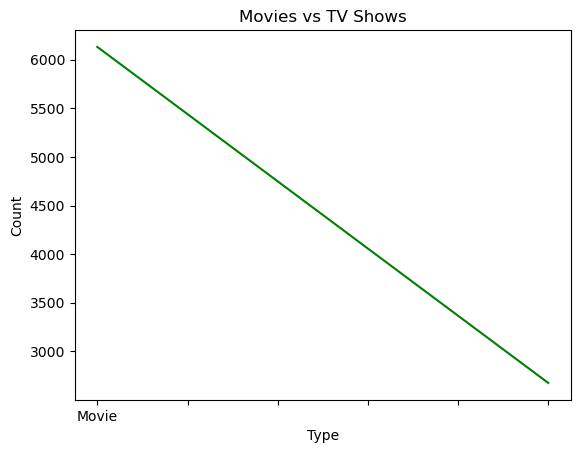

In [75]:
#1. Movies vs TV Shows
df['type'].value_counts().plot(kind='line',color='green')

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [ ]:
#Insight:
#Movies dominate Netflix, indicating higher focus on short-form content.

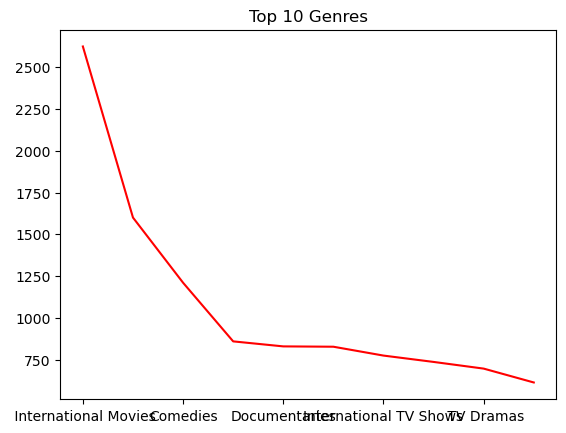

In [76]:
#2. Most Popular Genres
genres = df['listed_in'].str.split(',', expand=True).stack()

genres.value_counts().head(10).plot(kind='line',color='red')

plt.title("Top 10 Genres")
plt.show()

In [ ]:
#Insight:
#Drama and Comedy are the most popular genres globally.

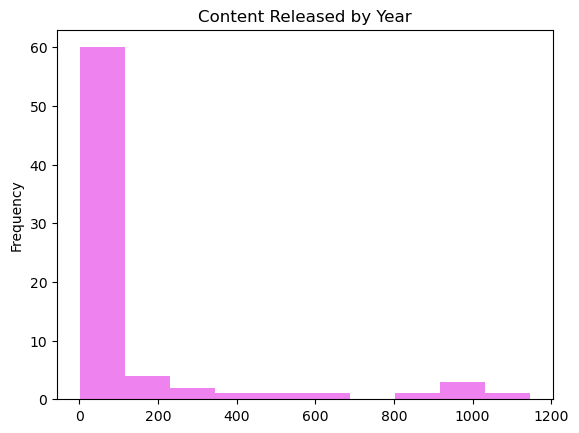

In [80]:
#3. Years with Highest Content Release
df['release_year'].value_counts().sort_index().plot(kind='hist',color='violet')

plt.title("Content Released by Year")
plt.show()

In [ ]:
# Insight:
# Content production increased rapidly after 2015.

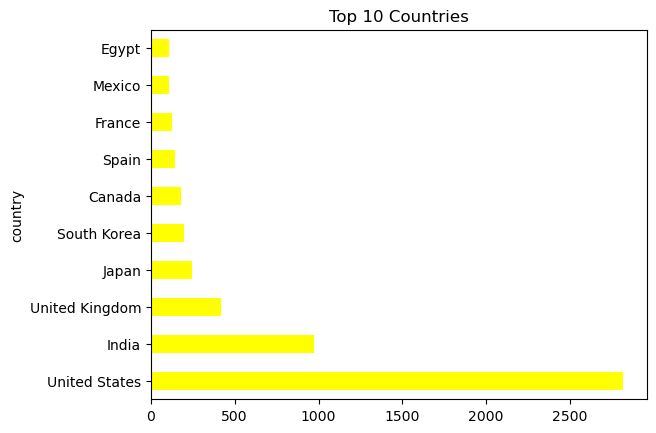

In [84]:
#4. Top Countries
df['country'].value_counts().head(10).plot(kind='barh',color='yellow')

plt.title("Top 10 Countries")
plt.show()

In [ ]:
# Insight:
# USA leads content production, followed by India and UK.

In [16]:
#5.Content Addition Trend over time
#Use errors='coerce' to handle unparseable dates
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
# Now you can safely extract the year
df['year_added'] = df['date_added'].dt.year
# This will now work without the error
print(df['year_added'].value_counts().sort_index())

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


In [ ]:
#Insights:
#Netflix has been adding more content every year, espically recently.

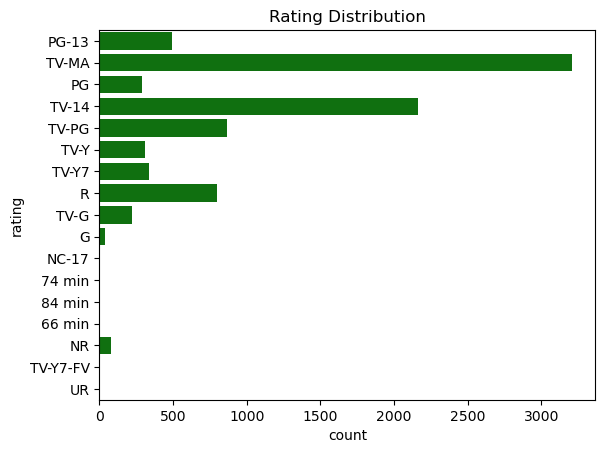

In [85]:
#6.Most frequent rating
df['rating'].value_counts()
sns.countplot(y='rating',data=df,color='green')
plt.title("Rating Distribution")
plt.show()

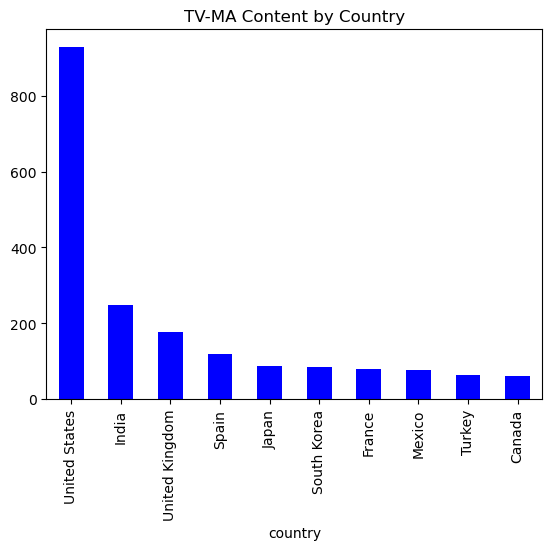

In [86]:
#7.Mature content by country
df[df['rating']=='TV-MA']['country'].value_counts().head(10).plot(kind='bar',color='b')
plt.title("TV-MA Content by Country")
plt.show()

In [20]:
# Insight:
# TV-MA rating is most common meaning content targets adults.

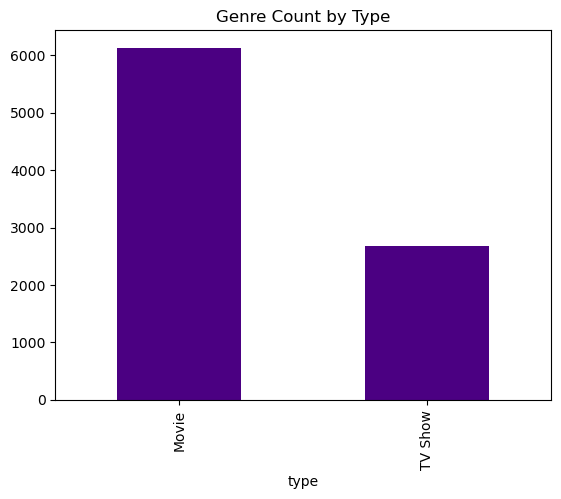

In [99]:
#8.Genres:Movies vs TV Shows
df.groupby('type')['listed_in'].count().plot(kind='bar',color='indigo')
plt.title("Genre Count by Type")
plt.show()

In [91]:
# Insight:
# Movies have more genre diversity than TV Shows.

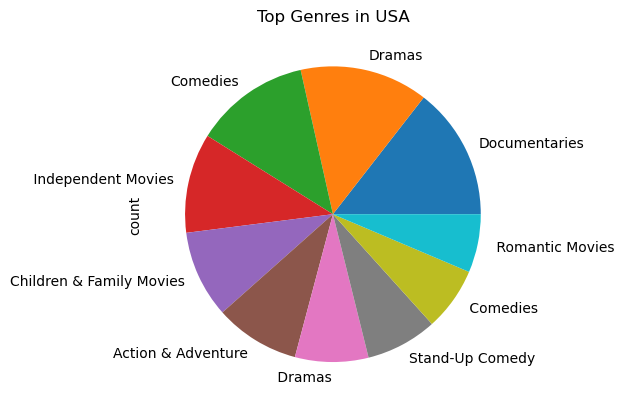

In [100]:
#9. Genres in USA
df[df['country']=='United States']['listed_in'].str.split(',').explode().value_counts().head(10).plot(kind='pie')

plt.title("Top Genres in USA")
plt.show()

In [ ]:
# Insight:
# Drama and Documentaries dominate in the USA.

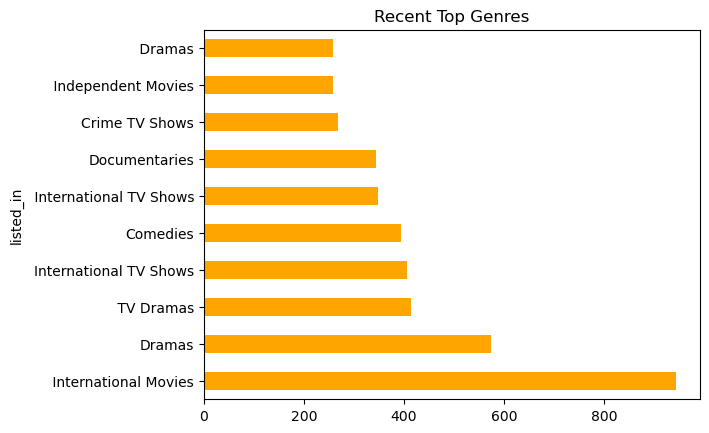

In [104]:
#10.Recent Popular Genres
recent = df[df['release_year'] >= df['release_year'].max()-3]

recent['listed_in'].str.split(',').explode().value_counts().head(10).plot(kind='barh',color='orange')

plt.title("Recent Top Genres")
plt.show()

In [ ]:
# Insight:
# Recent content focuses more on international and drama genres.

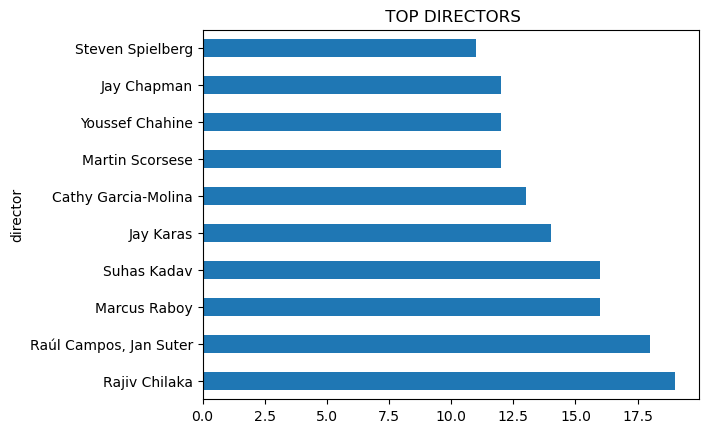

In [29]:
#11.Top Directors
df['director'].value_counts().head(10).plot(kind='barh')
plt.title(" TOP DIRECTORS")
plt.show()

In [30]:
# Certain directors appear frequently, meaning Netflix collaboration repeatedly

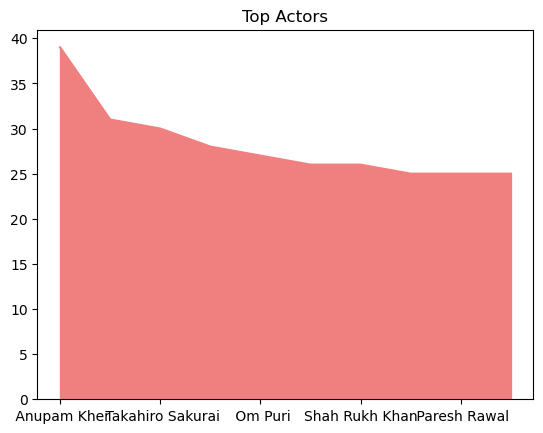

In [108]:
#12.Top Actors
actors = df['cast'].str.split(',', expand=True).stack()

actors.value_counts().head(10).plot(kind='area',color='lightcoral')

plt.title("Top Actors")
plt.show()

In [109]:
# Insight:
# Popular actors appear repeatedly in Netflix content.

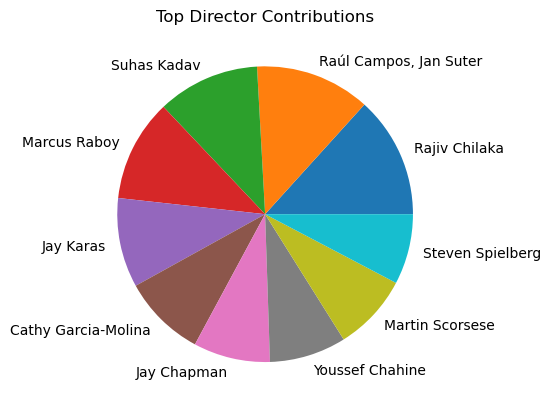

In [34]:
#13.Director-genre pair
df.groupby(['director']).size().sort_values(ascending=False).head(10).plot(kind='pie')
plt.title("Top Director Contributions")
plt.show()

In [35]:
# Insight:
# Some directors contribute significantly more content.

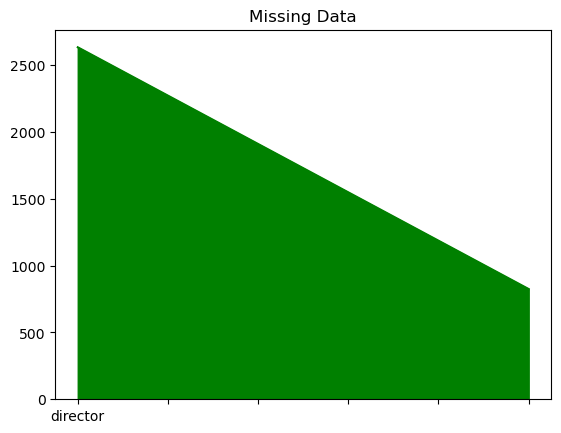

In [128]:
#14.Missing Data
df[['director','cast']].isnull().sum().plot(kind='area',color='green')
plt.title("Missing Data")
%matplotlib inline
plt.show()

In [ ]:
# Insight:
# Many entries lack director or cast information.

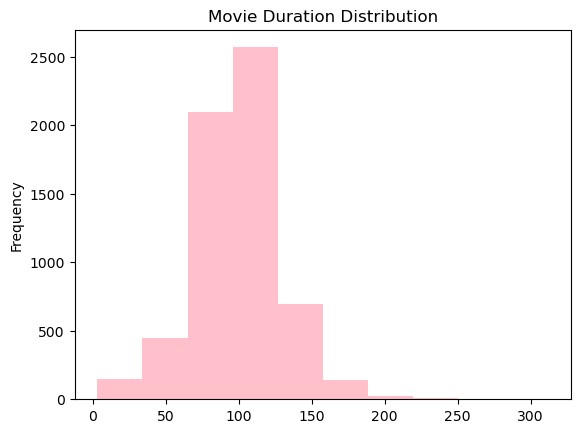

In [124]:
#15.Movie Duration Distribution
movies = df[df['type']=='Movie'].copy()
movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')
%matplotlib inline
movies['duration'].plot(kind='hist',color='pink')
plt.title("Movie Duration Distribution")
plt.show()

In [42]:
# Insight:
# Most movies are around 90–100 minutes long.

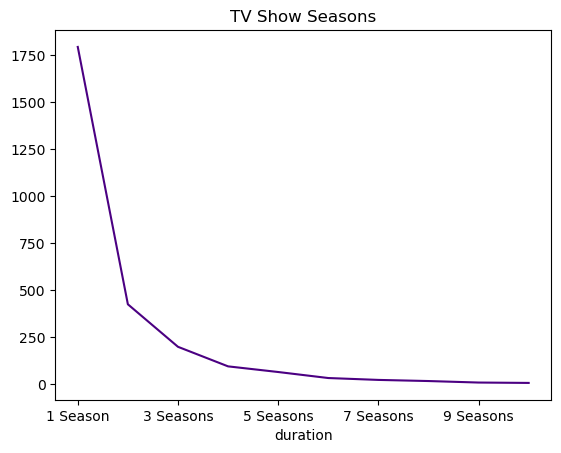

In [46]:
#16.TV Show seasons
tv = df[df['type']=='TV Show']
tv['duration'].value_counts().head(10).plot(kind='line',color='indigo')
plt.title("TV Show Seasons")
plt.show()

In [47]:
# Insight:
# Most shows have 1–2 seasons.

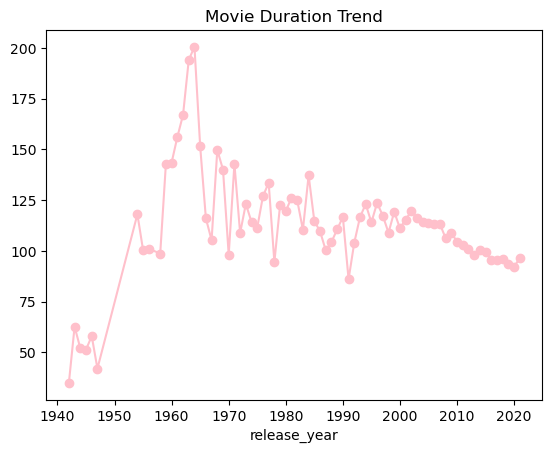

In [50]:
#17.Duration Trend
movies.groupby('release_year')['duration'].mean().plot(color='pink',marker='o')
plt.title("Movie Duration Trend")
plt.show()

In [51]:
# Insight:
# Movie duration has remained stable over time.

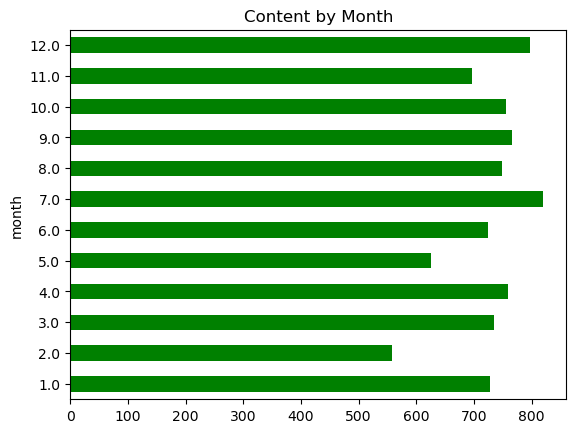

In [54]:
#18.Best month to add content
df['month'] = df['date_added'].dt.month
df['month'].value_counts().sort_index().plot(kind='barh',color='green')
plt.title("Content by Month")
plt.show()

In [56]:
#Insight:
# Most content is added in the second half of the year.

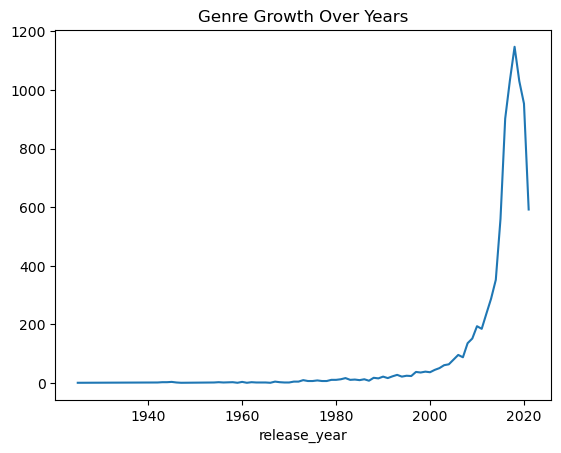

In [65]:
#19.Genre Distribution Over Years
df.groupby('release_year')['listed_in'].count().plot(kind='line')
plt.title("Genre Growth Over Years")
plt.show()

In [66]:
# Insight:
# Content diversity has increased over time.

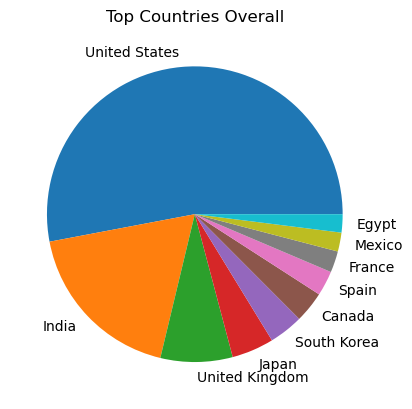

In [71]:
#20.Country vs Genre
df.groupby('country').size().sort_values(ascending=False).head(10).plot(kind='pie')
plt.title("Top Countries Overall")
plt.show()

In [ ]:
# Insight:
# Different countries contribute differently to Netflix’s content pool.